In [1]:
!pip install -q imbalanced-learn

print(" Done! Ready to go.")

 Done! Ready to go.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print("All libraries imported successfully")

Device: cuda
All libraries imported successfully


In [3]:
np.random.seed(42)
N = 5000

# ── EARTHQUAKE ──────────────────────────────────────────────
magnitude = np.concatenate([
    np.random.normal(5.5, 0.8, int(N * 0.75)),
    np.random.normal(7.2, 0.5, int(N * 0.25))
])
magnitude = np.clip(magnitude, 4.5, 9.5)

depth_km    = np.clip(np.random.exponential(50, N), 1, 700)
latitude    = np.random.uniform(-70, 70, N)
longitude   = np.random.uniform(-180, 180, N)
seismic_gap = np.random.exponential(30, N)
fault_dist  = np.abs(np.random.normal(20, 15, N))

eq_df = pd.DataFrame({
    'Magnitude'  : np.round(magnitude,   1),
    'Depth'      : np.round(depth_km,    1),
    'Latitude'   : np.round(latitude,    3),
    'Longitude'  : np.round(longitude,   3),
    'Seismic_Gap': np.round(seismic_gap, 1),
    'Fault_Dist' : np.round(fault_dist,  1),
})
eq_df.to_csv('earthquake.csv', index=False)

# ── FLOOD ────────────────────────────────────────────────────
M = 4000

rainfall_72h  = np.random.gamma(3, 20, M)
soil_moisture = np.random.beta(2, 3, M) * 100
river_level   = np.random.gamma(2, 1.5, M)
basin_area    = np.random.exponential(5000, M)
slope         = np.random.exponential(3, M)
land_cover    = np.random.randint(1, 6, M)
prev_flood    = np.random.poisson(1, M)

flood_score = (0.4 * (rainfall_72h / 100) +
               0.35 * (soil_moisture / 100) +
               0.25 * (river_level / 8) +
               np.random.normal(0, 0.08, M))
flood_label = (flood_score > np.percentile(flood_score, 65)).astype(int)

flood_df = pd.DataFrame({
    'Rainfall_72h'  : np.round(rainfall_72h,  1),
    'Soil_Moisture' : np.round(soil_moisture, 1),
    'River_Level'   : np.round(river_level,   2),
    'Basin_Area_km2': np.round(basin_area,    0),
    'Slope_deg'     : np.round(slope,         1),
    'Land_Cover'    : land_cover,
    'Prev_Floods'   : prev_flood,
    'Flood_Risk'    : flood_label,
})
flood_df.to_csv('flood.csv', index=False)

# ── HEATWAVE ─────────────────────────────────────────────────
K = 4000

max_temp        = np.random.normal(32, 8, K)
min_temp        = max_temp - np.random.uniform(8, 18, K)
humidity        = np.random.beta(2, 2, K) * 100
wet_bulb        = 0.7 * max_temp + 0.3 * humidity / 5
days_above_30   = np.random.poisson(5, K)
pressure_500hPa = np.random.normal(5870, 40, K)
urban_heat_idx  = np.random.uniform(0, 5, K)

heat_score = (0.4 * (max_temp / 50) +
              0.3  * (wet_bulb / 40) +
              0.3  * (days_above_30 / 10) +
              np.random.normal(0, 0.05, K))
heat_label = (heat_score > np.percentile(heat_score, 70)).astype(int)

heat_df = pd.DataFrame({
    'Max_Temp_C'     : np.round(max_temp,        1),
    'Min_Temp_C'     : np.round(min_temp,        1),
    'Humidity_pct'   : np.round(humidity,        1),
    'Wet_Bulb_C'     : np.round(wet_bulb,        1),
    'Days_Above_30'  : days_above_30,
    'Pressure_500hPa': np.round(pressure_500hPa, 0),
    'Urban_Heat_Idx' : np.round(urban_heat_idx,  2),
    'Heatwave_Risk'  : heat_label,
})
heat_df.to_csv('heatwave.csv', index=False)

print(f"earthquake.csv — {len(eq_df)} rows")
print(f"flood.csv      — {len(flood_df)} rows | events: {flood_label.sum()}")
print(f"heatwave.csv   — {len(heat_df)} rows | events: {heat_label.sum()}")
print("All 3 CSV files created.")

earthquake.csv — 5000 rows
flood.csv      — 4000 rows | events: 1400
heatwave.csv   — 4000 rows | events: 1200
All 3 CSV files created.


In [4]:
# Load CSVs
eq_df    = pd.read_csv('earthquake.csv')
flood_df = pd.read_csv('flood.csv')
heat_df  = pd.read_csv('heatwave.csv')

# Earthquake — Magnitude excluded from features, used only for label
eq_features    = ['Depth', 'Latitude', 'Longitude', 'Seismic_Gap', 'Fault_Dist']
flood_features = ['Rainfall_72h', 'Soil_Moisture', 'River_Level',
                  'Basin_Area_km2', 'Slope_deg', 'Land_Cover', 'Prev_Floods']
heat_features  = ['Max_Temp_C', 'Min_Temp_C', 'Humidity_pct', 'Wet_Bulb_C',
                  'Days_Above_30', 'Pressure_500hPa', 'Urban_Heat_Idx']

# Earthquake label
eq_df['label'] = (eq_df['Magnitude'] >= 6.5).astype(int)

# Prepare arrays
X_eq    = eq_df[eq_features].values.astype(np.float32)
y_eq    = eq_df['label'].values

X_flood = flood_df[flood_features].values.astype(np.float32)
y_flood = flood_df['Flood_Risk'].values

X_heat  = heat_df[heat_features].values.astype(np.float32)
y_heat  = heat_df['Heatwave_Risk'].values

print(f"Earthquake — {X_eq.shape[0]} samples | Events: {y_eq.sum()} | Features: {X_eq.shape[1]}")
print(f"Flood      — {X_flood.shape[0]} samples | Events: {y_flood.sum()} | Features: {X_flood.shape[1]}")
print(f"Heatwave   — {X_heat.shape[0]} samples | Events: {y_heat.sum()} | Features: {X_heat.shape[1]}")
print("All datasets ready")

Earthquake — 5000 samples | Events: 1617 | Features: 5
Flood      — 4000 samples | Events: 1400 | Features: 7
Heatwave   — 4000 samples | Events: 1200 | Features: 7
All datasets ready


In [5]:
class DisasterNet(nn.Module):
    def __init__(self, input_dim, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

test_model = DisasterNet(input_dim=5)
total_params = sum(p.numel() for p in test_model.parameters())
print(test_model)
print(f"\nTotal parameters: {total_params:,}")

DisasterNet(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Total parameters: 17,537


In [6]:
def prepare_loaders(X, y, test_size=0.2, batch_size=64, use_smote=True):
    # Split first, then scale — no val data leaks into scaler
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    # SMOTE on training split only
    if use_smote:
        sm = SMOTE(random_state=42)
        X_tr, y_tr = sm.fit_resample(X_tr, y_tr)
        print(f"  After SMOTE — train size: {len(y_tr)} | balance: {y_tr.mean():.2f}")

    def to_loader(Xd, yd, shuffle=True):
        ds = TensorDataset(
            torch.tensor(Xd, dtype=torch.float32),
            torch.tensor(yd, dtype=torch.float32))
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    return to_loader(X_tr, y_tr), to_loader(X_te, y_te, False), scaler


def train_model(name, X, y, epochs=60):
    print(f"\n{'='*45}\n  Training: {name}\n{'='*45}")
    train_loader, test_loader, scaler = prepare_loaders(X, y)

    model     = DisasterNet(input_dim=X.shape[1]).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(1, epochs + 1):
        # Training pass
        model.train()
        epoch_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        # Validation pass
        model.eval()
        correct = total = 0
        val_loss = 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                val_loss += criterion(out, yb).item()
                preds = (out >= 0.5).float()
                correct += (preds == yb).sum().item()
                total   += yb.size(0)

        val_losses.append(val_loss / len(test_loader))
        val_accs.append(correct / total)
        scheduler.step(val_losses[-1])

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}  Train Loss: {train_losses[-1]:.4f}"
                  f"  Val Loss: {val_losses[-1]:.4f}  Val Acc: {val_accs[-1]:.4f}")

    # Final evaluation
    all_preds, all_probs, all_true = [], [], []
    model.eval()
    with torch.no_grad():
        for Xb, yb in test_loader:
            probs = model(Xb.to(device)).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend((probs >= 0.5).astype(int))
            all_true.extend(yb.cpu().numpy().astype(int))

    print(f"\n  Results — {name}")
    print(classification_report(all_true, all_preds, target_names=['No Event', 'Event']))
    print(f"  AUC-ROC: {roc_auc_score(all_true, all_probs):.4f}")

    return model, scaler, train_losses, val_losses, val_accs, all_true, all_preds

print("Helper functions ready")

Helper functions ready


In [7]:
model_eq, scaler_eq, losses_eq, vloss_eq, accs_eq, true_eq, pred_eq = \
    train_model('Earthquake', X_eq, y_eq, epochs=60)
print("Earthquake model trained")

model_fl, scaler_fl, losses_fl, vloss_fl, accs_fl, true_fl, pred_fl = \
    train_model('Flood', X_flood, y_flood, epochs=60)
print("Flood model trained")

model_hw, scaler_hw, losses_hw, vloss_hw, accs_hw, true_hw, pred_hw = \
    train_model('Heatwave', X_heat, y_heat, epochs=60)
print("Heatwave model trained")
print("\nAll 3 models done!")


  Training: Earthquake
  After SMOTE — train size: 5412 | balance: 0.50
  Epoch  10  Train Loss: 0.6926  Val Loss: 0.6985  Val Acc: 0.4670
  Epoch  20  Train Loss: 0.6900  Val Loss: 0.6993  Val Acc: 0.4800
  Epoch  30  Train Loss: 0.6890  Val Loss: 0.6994  Val Acc: 0.4750
  Epoch  40  Train Loss: 0.6889  Val Loss: 0.6965  Val Acc: 0.4890
  Epoch  50  Train Loss: 0.6885  Val Loss: 0.7011  Val Acc: 0.4600
  Epoch  60  Train Loss: 0.6893  Val Loss: 0.6991  Val Acc: 0.4770

  Results — Earthquake
              precision    recall  f1-score   support

    No Event       0.69      0.42      0.52       677
       Event       0.33      0.61      0.43       323

    accuracy                           0.48      1000
   macro avg       0.51      0.51      0.47      1000
weighted avg       0.57      0.48      0.49      1000

  AUC-ROC: 0.5198
Earthquake model trained

  Training: Flood
  After SMOTE — train size: 4160 | balance: 0.50
  Epoch  10  Train Loss: 0.3216  Val Loss: 0.2825  Val Acc: 0.8

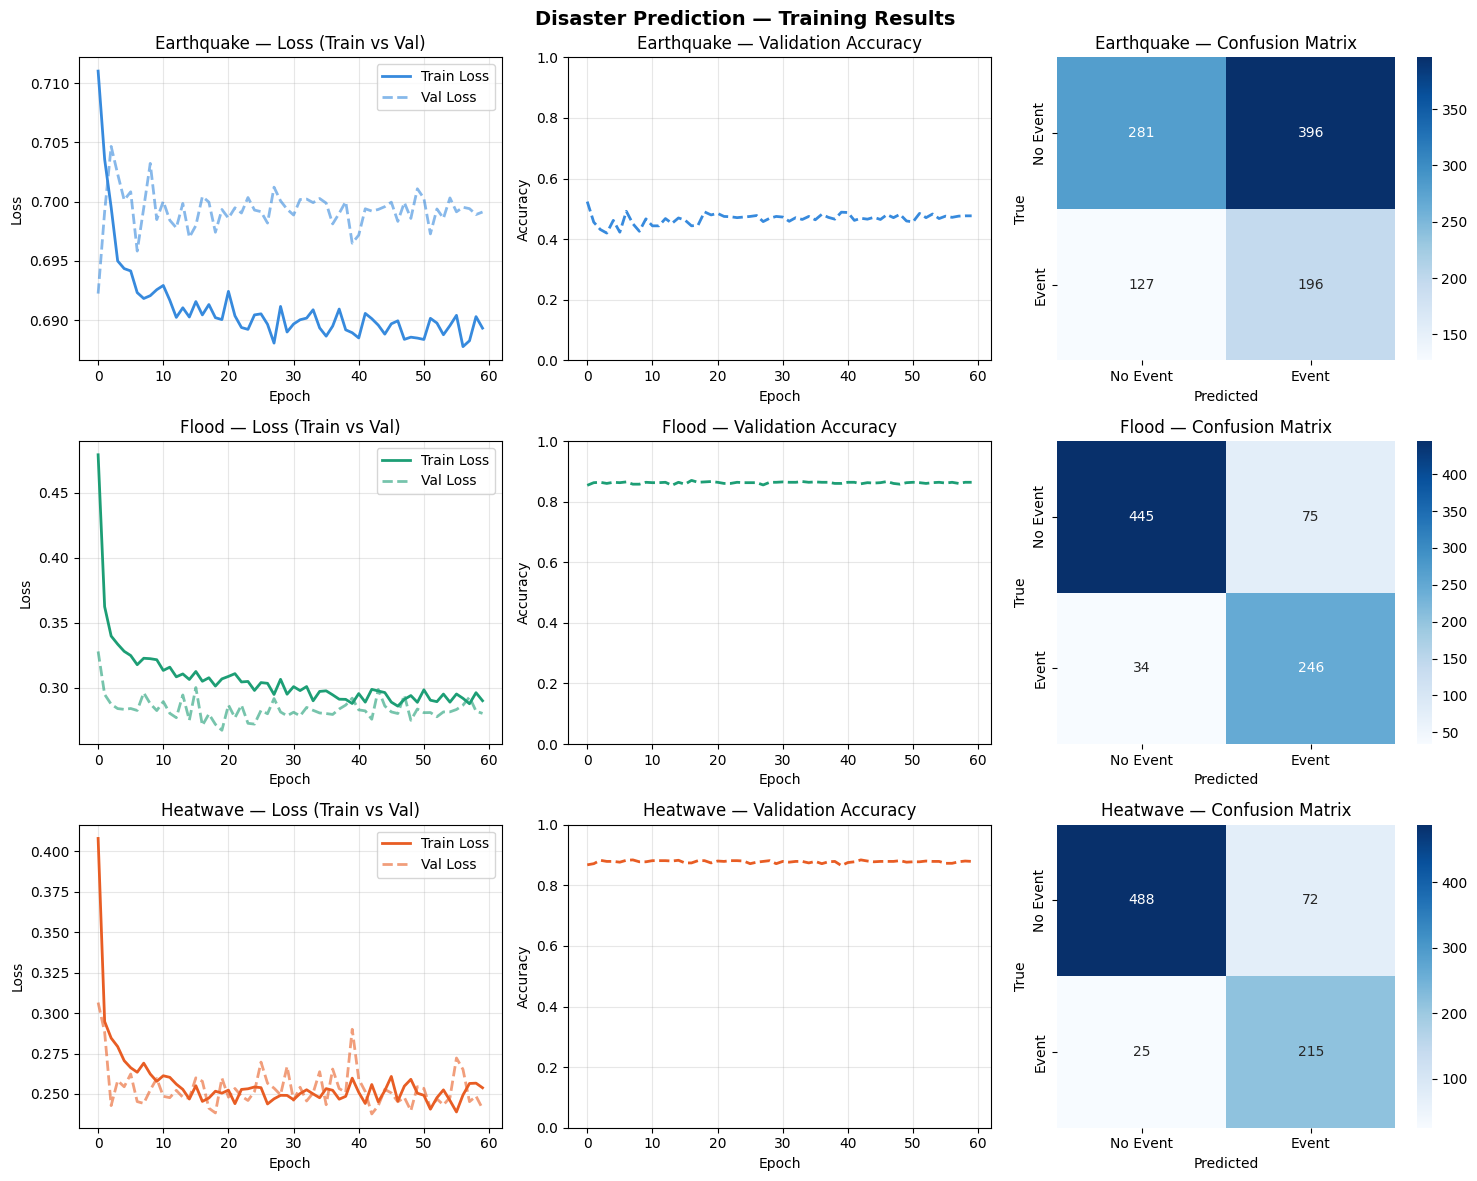

Plot saved as results.png


In [8]:
names   = ['Earthquake', 'Flood', 'Heatwave']
tlosses = [losses_eq, losses_fl, losses_hw]
vlosses = [vloss_eq,  vloss_fl,  vloss_hw]
accs    = [accs_eq,   accs_fl,   accs_hw]
trues   = [true_eq,   true_fl,   true_hw]
preds   = [pred_eq,   pred_fl,   pred_hw]
colors  = ['#378ADD', '#1D9E75', '#E85D24']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Disaster Prediction — Training Results',
             fontsize=14, fontweight='bold')

for i, (name, tl, vl, acc, yt, yp, col) \
        in enumerate(zip(names, tlosses, vlosses, accs, trues, preds, colors)):

    axes[i][0].plot(tl, color=col, linewidth=2, label='Train Loss')
    axes[i][0].plot(vl, color=col, linewidth=2, linestyle='--',
                    alpha=0.6, label='Val Loss')
    axes[i][0].set_title(f'{name} — Loss (Train vs Val)')
    axes[i][0].set_xlabel('Epoch')
    axes[i][0].set_ylabel('Loss')
    axes[i][0].legend()
    axes[i][0].grid(alpha=0.3)

    axes[i][1].plot(acc, color=col, linewidth=2, linestyle='--')
    axes[i][1].set_title(f'{name} — Validation Accuracy')
    axes[i][1].set_xlabel('Epoch')
    axes[i][1].set_ylabel('Accuracy')
    axes[i][1].set_ylim(0, 1)
    axes[i][1].grid(alpha=0.3)

    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[i][2],
                xticklabels=['No Event', 'Event'],
                yticklabels=['No Event', 'Event'])
    axes[i][2].set_title(f'{name} — Confusion Matrix')
    axes[i][2].set_ylabel('True')
    axes[i][2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as results.png")

In [9]:
import pickle

def predict(disaster_type, values):
    models  = {'earthquake': model_eq,  'flood': model_fl,  'heatwave': model_hw}
    scalers = {'earthquake': scaler_eq, 'flood': scaler_fl, 'heatwave': scaler_hw}
    m = models[disaster_type.lower()]
    s = scalers[disaster_type.lower()]
    x = np.array(values, dtype=np.float32).reshape(1, -1)
    x = s.transform(x)
    m.eval()
    with torch.no_grad():
        prob = m(torch.tensor(x).to(device)).item()
    label = "HIGH RISK" if prob >= 0.5 else "LOW RISK"
    print(f"\n  Type        : {disaster_type.upper()}")
    print(f"  Probability : {prob*100:.1f}%")
    print(f"  Prediction  : {label}")
    return prob

# Earthquake: [Depth, Latitude, Longitude, Seismic_Gap, Fault_Dist]
predict('earthquake', [35.0, 38.3, 142.3, 5.0, 2.5])

# Flood: [Rainfall_72h, Soil_Moisture, River_Level,
#         Basin_Area_km2, Slope_deg, Land_Cover, Prev_Floods]
predict('flood', [180.0, 88.0, 5.5, 12000.0, 1.5, 5, 3])

# Heatwave: [Max_Temp_C, Min_Temp_C, Humidity_pct,
#            Wet_Bulb_C, Days_Above_30, Pressure_500hPa, Urban_Heat_Idx]
predict('heatwave', [44.0, 30.0, 72.0, 36.0, 9, 5920.0, 4.5])

# Save
torch.save(model_eq.state_dict(), 'model_earthquake.pt')
torch.save(model_fl.state_dict(), 'model_flood.pt')
torch.save(model_hw.state_dict(), 'model_heatwave.pt')

with open('scalers.pkl', 'wb') as f:
    pickle.dump({'earthquake': scaler_eq,
                 'flood'     : scaler_fl,
                 'heatwave'  : scaler_hw}, f)

print("\nmodel_earthquake.pt saved")
print("model_flood.pt saved")
print("model_heatwave.pt saved")
print("scalers.pkl saved")
print("\nDownload from the Files panel (folder icon on left sidebar)")


  Type        : EARTHQUAKE
  Probability : 51.5%
  Prediction  : HIGH RISK

  Type        : FLOOD
  Probability : 100.0%
  Prediction  : HIGH RISK

  Type        : HEATWAVE
  Probability : 99.9%
  Prediction  : HIGH RISK

model_earthquake.pt saved
model_flood.pt saved
model_heatwave.pt saved
scalers.pkl saved

Download from the Files panel (folder icon on left sidebar)
